In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
from metrics.graph import *
from utils.results import *


In [2]:
import pickle

subset = 'jpmf_grid'
# subset = 'toyMedium'

def load_results(subset):
    global results_by_label

    with open(f'results/pc/{subset}.pkl', 'rb') as f:
        results_pc = pickle.load(f)
    with open(f'results/ges/{subset}.pkl', 'rb') as f:
        results_ges = pickle.load(f)
    with open(f'results/hc/{subset}.pkl', 'rb') as f:
        results_hc = pickle.load(f)


    # with open(f'results/ea_ues/{subset}.pkl', 'rb') as f:
    #     results_ea_ues = pickle.load(f)
    # with open(f'results/ea_ies/{subset}.pkl', 'rb') as f:
    #     results_ea_ies = pickle.load(f)
    # with open(f'results/ea_fes/{subset}.pkl', 'rb') as f:
    #     results_ea_fes = pickle.load(f)

    # with open(f'results/ea_upu/{subset}.pkl', 'rb') as f:
    #     results_ea_upu = pickle.load(f)
    # with open(f'results/ea_ipu/{subset}.pkl', 'rb') as f:
    #     results_ea_ipu = pickle.load(f)
    
    with open(f'results/ea_final_greedy/{subset}.pkl', 'rb') as f:
        results_ea_final_greedy = pickle.load(f)

    results_by_label = {
        "PC": results_pc,
        "GES": results_ges,
        "HC": results_hc,
        "EA Final Greedy": results_ea_final_greedy,
        # "EA Uninformed": results_ea_ues,
        # "EA Informed": results_ea_ies,
        # "EA Fully Informed": results_ea_fes,
        # "EA Uninformed (PU)": results_ea_upu,
        # "EA Informed (PU)": results_ea_ipu,
    }
    
load_results(subset)
mapping="experiments/RQ1/1.1/grid_mapping.csv"
mapping="experiments/RQ1/jpmf_grid/grid_mapping.csv"

x_col="target_mi"
y_col="syn_cutoff"

In [6]:
from pgmpy.base import DAG
# dag = pgmpy_base.DAG()
dag = DAG()
dag.add_nodes_from(each_rep.true_dags[0].nodes())
dag.add_edges_from(each_rep.true_dags[0].edges())
pdag = dag.to_pdag()

In [5]:
each_rep = results_by_label["EA Final Greedy"][0]

In [7]:
from pgmpy.base import DAG as _pgmpy_DAG
from pgmpy.estimators import BIC

def score_dag(data, graph):
    # Convert networkx DiGraph to pgmpy DAG
    dag_pg = _pgmpy_DAG()
    dag_pg.add_nodes_from(graph.nodes())
    dag_pg.add_edges_from(graph.edges())
    dag_pg.to_pdag()
    scorer = BIC(data=data)
    return scorer.score(dag_pg)


In [9]:
from metrics.graph import evaluate_colliders

for title, results in results_by_label.items():
    for each_rep in results:
        learned_dags = each_rep.learned_dags
        true_dags = each_rep.true_dags
        max_score = {key: score_dag(each_rep.df_by_id[key], true_dags[key]) for key, dag in true_dags.items()}
        bic_scores = {key: score_dag(each_rep.df_by_id[key], learned_dags[key]) for key, in learned_dags.keys()}

        each_rep.max_score = max_score
        each_rep.bic_scores = bic_scores
        each_rep_eval_metrics = {}
        #     for idx in range(len(true_dags)):
        #         each_rep_eval_metrics[idx] = compare_dags(true_dag=true_dags[idx], learned_dag=learned_cpdags[idx])
        #         each_rep_eval_metrics[idx].update(evaluate_colliders(metadata_df=each_rep.metadata[idx], learned_dag=learned_cpdags[idx]))
        #     each_rep.eval_metrics = pd.DataFrame(each_rep_eval_metrics).T
        # except Exception as e:
        #     print(f"Error processing {title}: {e}")

KeyError: 1

In [ ]:
ea = results_by_label["EA Final Greedy"]
hc = results_by_label["HC"]
ges = results_by_label["GES"]

                 mean      median           min          max
delta_ea   421.796785  362.890277  0.000000e+00  1231.952490
delta_hc   410.749399  221.079242 -2.535232e+01  1409.299811
delta_ges  472.803407  313.564076 -2.910383e-11  1927.049706
best_alg
delta_ea     17
delta_hc     11
delta_ges     8
Name: count, dtype: int64

Within Δ <= 2:
  ea: 5.56%
  hc: 2.78%
  ges: 2.78%

Within Δ <= 6:
  ea: 5.56%
  hc: 2.78%
  ges: 2.78%

Within Δ <= 10:
  ea: 8.33%
  hc: 2.78%
  ges: 2.78%

      d    max_score        hc_bic   delta_hc
30  30 -81737.00902 -81711.656701 -25.352319

      d      max_score        ges_bic     delta_ges
13  13 -113240.135637 -113240.135637 -2.910383e-11


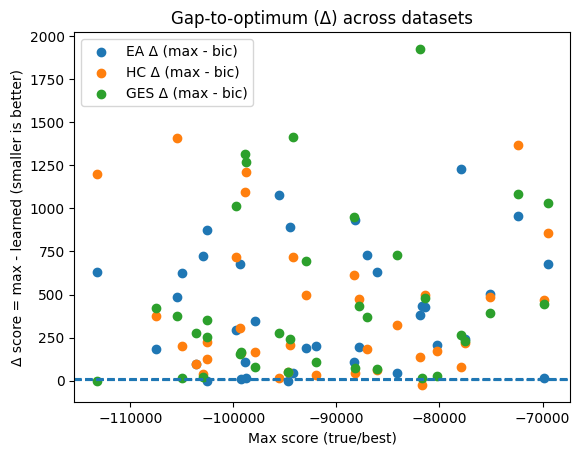

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

r_idx = 0
D = 36

# --- collect scores ---
ea_bic = np.array([ea[r_idx].bic_scores[d][-1] for d in range(D)], dtype=float)  # final greedy score
hc_bic = np.array([hc[r_idx].bic_scores[d]      for d in range(D)], dtype=float)
ges_bic= np.array([ges[r_idx].bic_scores[d]     for d in range(D)], dtype=float)

# pick one max_score vector (should be identical across algs if it's truly "the max/true")
max_score = np.array([ea[r_idx].max_score[d] for d in range(D)], dtype=float)

# optional sanity checks:
# print("max_score equals HC max_score?", np.allclose(max_score, [hc[r_idx].max_score[d] for d in range(D)]))
# print("max_score equals GES max_score?", np.allclose(max_score, [ges[r_idx].max_score[d] for d in range(D)]))

# --- build table + deltas (gap to max) ---
df = pd.DataFrame({
    "d": np.arange(D),
    "max_score": max_score,
    "ea_bic": ea_bic,
    "hc_bic": hc_bic,
    "ges_bic": ges_bic,
})

for alg in ["ea", "hc", "ges"]:
    df[f"delta_{alg}"] = df["max_score"] - df[f"{alg}_bic"]  # smaller is better

# --- summary comparison ---
summary = df[[f"delta_{a}" for a in ["ea","hc","ges"]]].agg(["mean","median","min","max"])
print(summary.T)

# which algorithm is closest to max most often?
df["best_alg"] = df[[f"delta_{a}" for a in ["ea","hc","ges"]]].idxmin(axis=1)
print(df["best_alg"].value_counts())

# how often within common “near-tie” thresholds?
for t in [2, 6, 10]:
    print(f"\nWithin Δ <= {t}:")
    for a in ["ea","hc","ges"]:
        print(f"  {a}: {(df[f'delta_{a}'] <= t).mean():.2%}")

# flag weird cases where learned score beats "max"
for a in ["ea","hc","ges"]:
    bad = df[df[f"delta_{a}"] < 0][["d","max_score",f"{a}_bic",f"delta_{a}"]]
    if len(bad):
        print(f"\nWARNING: {a} has {len(bad)} cases with delta < 0 (beats 'max'):\n", bad)

# --- quick plot: gap-to-max vs max_score ---
plt.scatter(df["max_score"], df["delta_ea"], label="EA Δ (max - bic)")
plt.scatter(df["max_score"], df["delta_hc"], label="HC Δ (max - bic)")
plt.scatter(df["max_score"], df["delta_ges"], label="GES Δ (max - bic)")
plt.axhline(2, linestyle="--")
plt.axhline(6, linestyle="--")
plt.axhline(10, linestyle="--")
plt.xlabel("Max score (true/best)")
plt.ylabel("Δ score = max - learned (smaller is better)")
plt.title("Gap-to-optimum (Δ) across datasets")
plt.legend()
plt.show()


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# --- UI ---
metric_dropdown = widgets.Dropdown(
    options=["Recall (Collider)", "F1 (Collider)", "SHD", "Recall (Synergy)"],
    value="Recall (Collider)",
    description="Metric:",
)

out = widgets.Output()

def render(metric: str):
    """Render the heatmap for the selected metric."""
    with out:
        clear_output(wait=True)

        # Important: close prior figures to avoid stacking / memory leaks
        plt.close("all")

        fig, axes = plot_final_heatmap(
            results_by_label,
            mapping=mapping,
            subset_metrics=[metric],
            plot_metric=metric,
            x_col=x_col,
            y_col=y_col,
        )

        # Ensure the latest figure is shown in the output area
        plt.show()

def on_metric_change(change):
    if change["name"] == "value":
        render(change["new"])

metric_dropdown.observe(on_metric_change, names="value")

# Display UI + initial render
display(widgets.VBox([metric_dropdown, out]))
render(metric_dropdown.value)
